# Google Colab Lab Assignment -Pretrained Model

**Course Name:** `Deep Learning`

**Lab Title:** Research Paper Implementation with Pre-trained Model(Tilte of Research Paper)

**Student Name:** `Sanket Rath`

**Student ID:** `202301100006`

**Date of Submission:** `05-04-2026`

**Group Members**: `Ayush Chandekar, Harsh Kumar, Aarya Malghe`

**Research Paper Study and Implementation**

**Instructions:**

1. Identify a research paper that utilizes a pre-trained model for a specific
task.

2. Study the methodology, dataset, and model used in the research paper.

3. Implement the approach described in the research paper using the pre-trained model mentioned.

4. Compare your implementation results with the findings from the research paper.


**Objective**
1.   Study a research paper utilizing a pre-trained model.
2.   Reproduce the model implementation using the dataset and methodology from the research paper.
3.   Fine-tune the pre-trained model and optimize hyperparameters.
3.   Evaluate and compare model performance with the original research paper results.









**Task 1: Research Paper Selection and Dataset Preparation (2 hours)**

**Instructions:**

1. Select a research paper that applies a pre-trained model (e.g., VGG, ResNet, EfficientNet, etc.).

2. Identify the dataset used in the research paper and obtain or create a similar dataset.(**Mention Dataset Link and Description**)

3. Perform necessary preprocessing steps:

 Resize images to match the model input dimensions.

 Apply data augmentation techniques if applicable.

4. Split the dataset into training, validation, and testing sets.

**Research Paper Details**

- Link: https://drive.google.com/drive/folders/1RYYN1y-0Mv3-W3YFJDLLTh2jxNCujhiA?usp=sharing

<br>

**Description of Research Paper**
<br>
This paper proposes improving neural network robustness to adversarial attacks by applying low-pass (Gaussian) filtering to remove high-frequency noise. The study uses CIFAR-10, ImageNet, Natural Images, and Rock–Paper–Scissors datasets to test robustness across varying complexity. It evaluates two models—a simple CNN (SimConvNet) and EfficientNetB3—trained from scratch, analyzing how low-pass filtering improves classification accuracy under adversarial attacks.
<br>
<br>
For this Practical, we will be using the CIFAR-10 dataset. CIFAR-10 is a widely used benchmark dataset for image classification tasks in deep learning.

- **Total images:** `60,000`
- **Classes:** `10 (airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck)`
- **Image size:** `32x32 pixels, RGB (3 channels)`
- **Split:** `50,000 training images + 10,000 test images`
- **Dataset Link:** https://www.cs.toronto.edu/~kriz/cifar.html

<br>

**Going forward with the Task 1**

TensorFlow Version: 2.19.0
Training set shape  : (50000, 32, 32, 3)
Test set shape      : (10000, 32, 32, 3)


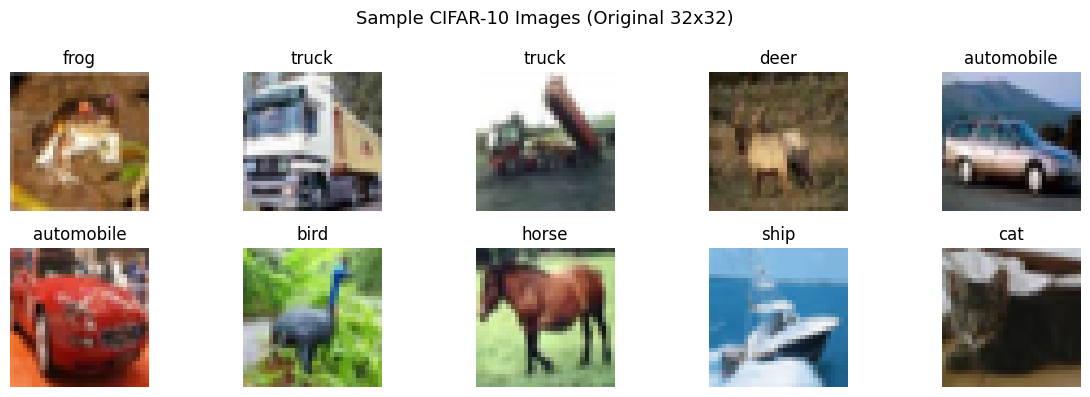

In [2]:
# Install & Import Required Libraries
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split

print("TensorFlow Version:", tf.__version__)

# Load CIFAR-10 Dataset
(X_train_raw, y_train_raw), (X_test_raw, y_test_raw) = cifar10.load_data()

print(f"Training set shape  : {X_train_raw.shape}")
print(f"Test set shape      : {X_test_raw.shape}")

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

# Visualize Sample Images
plt.figure(figsize=(12, 4))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(X_train_raw[i])
    plt.title(class_names[y_train_raw[i][0]])
    plt.axis('off')
plt.suptitle("Sample CIFAR-10 Images (Original 32x32)", fontsize=13)
plt.tight_layout()
plt.show()

In [3]:
# Resize Images to ResNet Input (224x224)
IMAGE_SIZE = 64

def resize_images_in_batches(images, size, batch_size=1000):
    """Resize images in small batches to avoid GPU OOM."""
    resized_list = []
    total = len(images)

    for start in range(0, total, batch_size):
        end = min(start + batch_size, total)
        batch = tf.constant(images[start:end], dtype=tf.float32)
        resized_batch = tf.image.resize(batch, [size, size])
        resized_list.append(resized_batch.numpy().astype(np.uint8))

        # Progress update
        print(f"  Resized {end}/{total} images...", end="\r")

    print(f"\nDone!")
    return np.concatenate(resized_list, axis=0)

X_train_resized = resize_images_in_batches(X_train_raw, IMAGE_SIZE)
print(f"\nResized Train shape : {X_train_resized.shape}")

  Resized 50000/50000 images...
Done!

Resized Train shape : (50000, 64, 64, 3)


In [4]:
X_test_resized  = resize_images_in_batches(X_test_raw,  IMAGE_SIZE)

print(f"\nResized Train shape : {X_train_resized.shape}")
print(f"Resized Test shape  : {X_test_resized.shape}")

# Apply ResNet-specific Preprocessing

# ResNet was trained on ImageNet with specific mean subtraction
# keras provides built-in preprocess_input for this

from tensorflow.keras.applications.resnet50 import preprocess_input

X_train_norm = preprocess_input(X_train_resized.astype(np.float32))
X_test_norm  = preprocess_input(X_test_resized.astype(np.float32))

print("\nResNet-specific preprocessing applied (ImageNet mean subtraction)")
print(f"Pixel value range after preprocessing: [{X_train_norm.min():.2f}, {X_train_norm.max():.2f}]")

# One-Hot Encode Labels

NUM_CLASSES = 10
y_train_ohe = to_categorical(y_train_raw, NUM_CLASSES)
y_test_ohe  = to_categorical(y_test_raw,  NUM_CLASSES)

print(f"\nOne-hot Train labels shape : {y_train_ohe.shape}")
print(f"One-hot Test labels shape  : {y_test_ohe.shape}")

# Train / Validation / Test Split

X_train, X_val, y_train, y_val = train_test_split(
    X_train_norm, y_train_ohe,
    test_size=0.20,
    random_state=42,
    stratify=y_train_raw
)

X_test = X_test_norm
y_test = y_test_ohe

print(f"\nFinal Split Summary:")
print(f"  Training   : {X_train.shape[0]} images")
print(f"  Validation : {X_val.shape[0]}  images")
print(f"  Test       : {X_test.shape[0]}  images")

  Resized 10000/10000 images...
Done!

Resized Train shape : (50000, 64, 64, 3)
Resized Test shape  : (10000, 64, 64, 3)

ResNet-specific preprocessing applied (ImageNet mean subtraction)
Pixel value range after preprocessing: [-123.68, 151.06]

One-hot Train labels shape : (50000, 10)
One-hot Test labels shape  : (10000, 10)

Final Split Summary:
  Training   : 40000 images
  Validation : 10000  images
  Test       : 10000  images


**Task 2: Model Implementation and Fine-tuning**

**Instructions:**

1. Implement the pre-trained model as described in the research paper.

2. Visualize feature maps of few layers

3. Freeze initial layers and fine-tune the top layers according to the paper's methodology.

4. Optimize hyperparameters such as:

  Learning rate

  Batch size

  Number of epochs

  Optimizer choice (Adam, SGD, RMSprop, etc.)

4. Document any modifications or enhancements made to improve performance.

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
ResNet50 loaded. Total layers: 175
Frozen layers    : 155
Trainable layers : 20

========== Hyperparameters ==========
Learning Rate : 0.0001
Batch Size    : 32
Epochs        : 20
Optimizer     : Adam


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 64, 64, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 70, 70, 3) │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 32, 32,    │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 32, 32,    │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 32, 32,    │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 34, 34,    │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 16, 16,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 16, 16,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 16, 16,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 16, 16,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 16, 16,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 16, 16,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 16, 16,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 16, 16,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 16, 16,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 16, 16,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 16, 16,    │      1,024 │ conv2_block1_3_c

 Total params: 24,154,634 (92.14 MB)

 Trainable params: 9,494,154 (36.22 MB)

 Non-trainable params: 14,660,480 (55.93 MB)


Starting Training...

Epoch 1/20
1249/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.5205 - loss: 1.4777
Epoch 1: val_accuracy improved from None to 0.79390, saving model to best_resnet50_cifar10.keras

Epoch 1: finished saving model to best_resnet50_cifar10.keras
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 63s 32ms/step - accuracy: 0.6406 - loss: 1.1073 - val_accuracy: 0.7939 - val_loss: 0.6161 - learning_rate: 1.0000e-04
Epoch 2/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.7810 - loss: 0.6674
Epoch 2: val_accuracy improved from 0.79390 to 0.81690, saving model to best_resnet50_cifar10.keras

Epoch 2: finished saving model to best_resnet50_cifar10.keras
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 31s 25ms/step - accuracy: 0.7886 - loss: 0.6523 - val_accuracy: 0.8169 - val_loss: 0.5448 - learning_rate: 1.0000e-04
Epoch 3/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.8481 - loss: 0.4565
Epoch 3: val_accuracy improved from 0.81690 to 0.82510, saving model to best_resnet50_cif

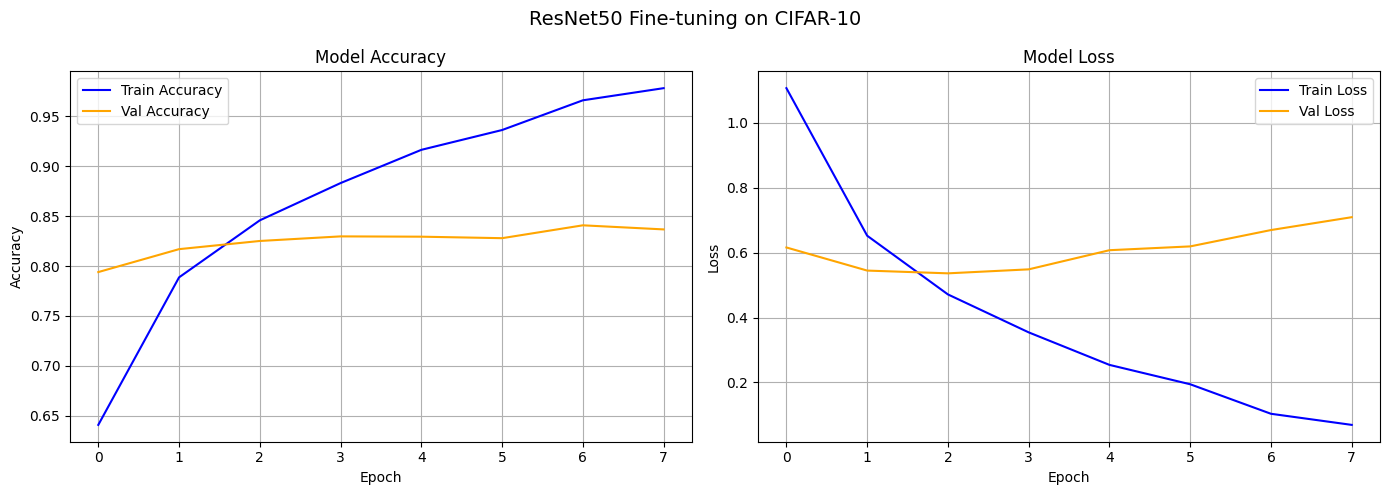

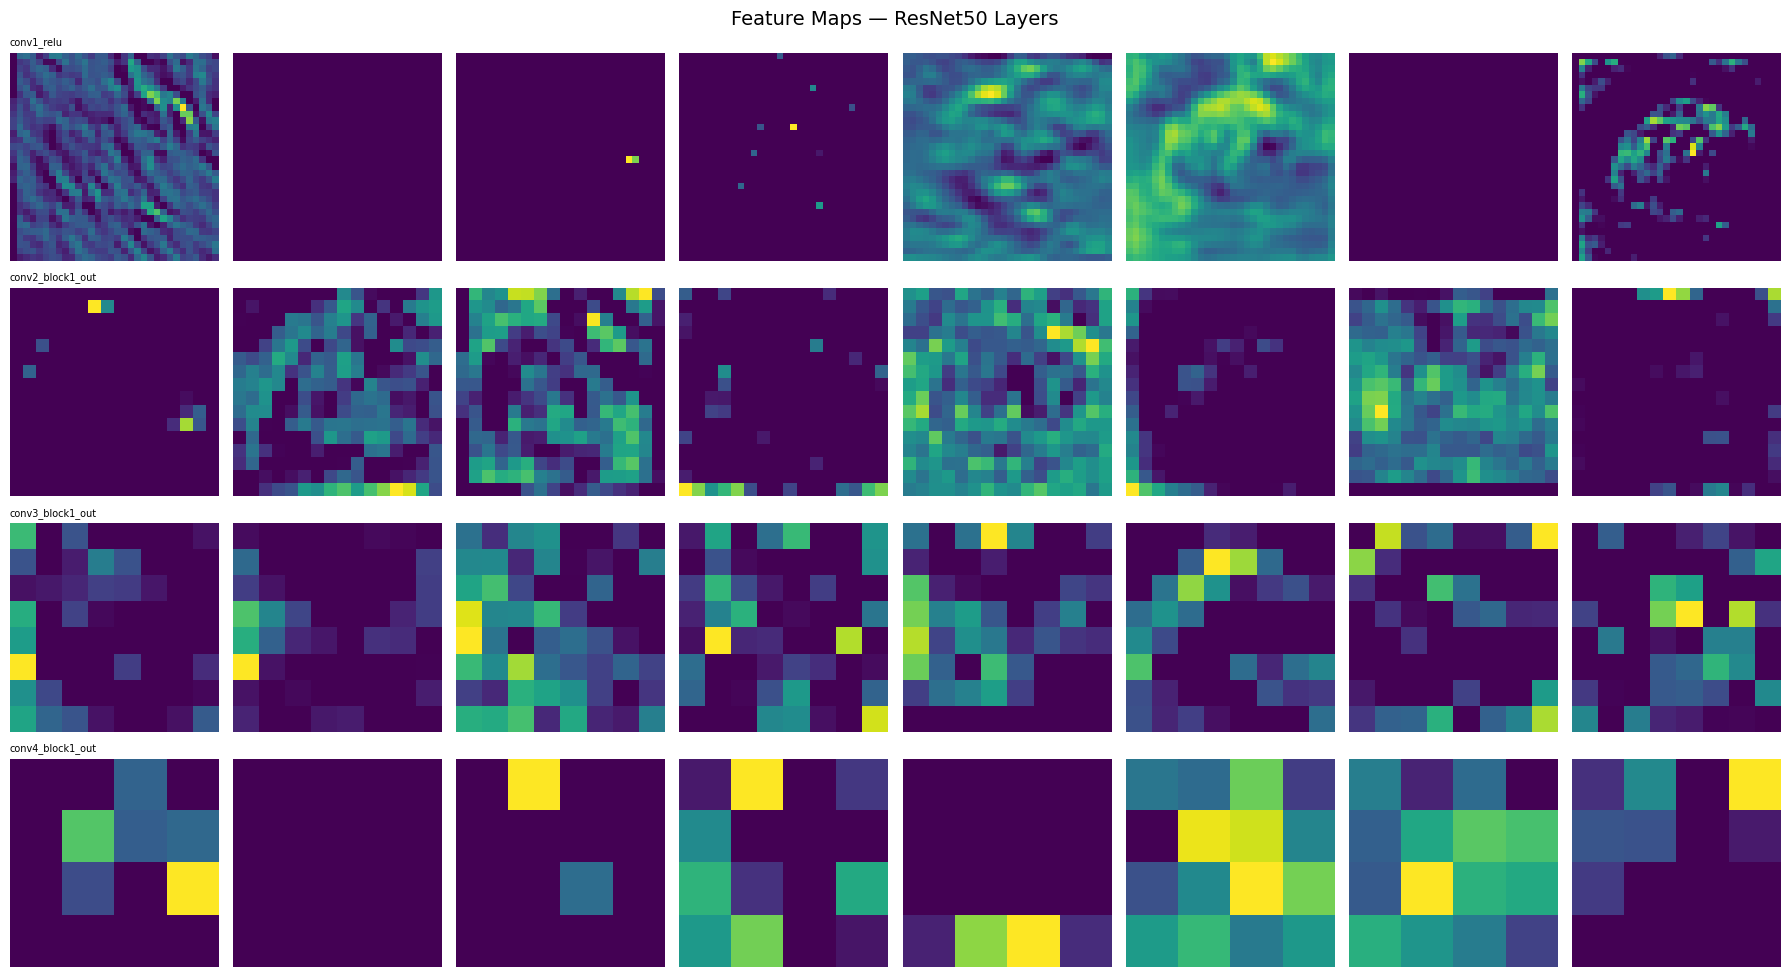

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.8182 - loss: 0.5550

========== Test Results ==========
Test Accuracy : 81.82%
Test Loss     : 0.5550


In [5]:
# TASK 2: ResNet50 Implementation, Feature Maps & Fine-Tuning

from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import gc

# Clear previous session to free GPU memory
tf.keras.backend.clear_session()
gc.collect()

#Build ResNet50 with Pretrained ImageNet Weights

base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3)
)

print(f"ResNet50 loaded. Total layers: {len(base_model.layers)}")


#Freeze Initial Layers, Unfreeze Last 20

for layer in base_model.layers:
    layer.trainable = False

for layer in base_model.layers[-20:]:
    layer.trainable = True

frozen    = sum(1 for l in base_model.layers if not l.trainable)
trainable = sum(1 for l in base_model.layers if l.trainable)
print(f"Frozen layers    : {frozen}")
print(f"Trainable layers : {trainable}")


#Add Custom Classification Head

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.4)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
output = Dense(NUM_CLASSES, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)


# Hyperparameters & Compile

LEARNING_RATE = 1e-4
BATCH_SIZE    = 32
EPOCHS        = 20

model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print(f"\n========== Hyperparameters ==========")
print(f"Learning Rate : {LEARNING_RATE}")
print(f"Batch Size    : {BATCH_SIZE}")
print(f"Epochs        : {EPOCHS}")
print(f"Optimizer     : Adam")
print(f"=====================================")

model.summary()

# Callbacks

callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1
    ),
    ModelCheckpoint(
        'best_resnet50_cifar10.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]


# Train

print("\nStarting Training...\n")

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1
)


#Plot Training History

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'],     label='Train Accuracy', color='blue')
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy',   color='orange')
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history.history['loss'],     label='Train Loss', color='blue')
axes[1].plot(history.history['val_loss'], label='Val Loss',   color='orange')
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.suptitle("ResNet50 Fine-tuning on CIFAR-10", fontsize=14)
plt.tight_layout()
plt.show()


# Visualize Feature Maps

layer_names = [
    'conv1_relu',
    'conv2_block1_out',
    'conv3_block1_out',
    'conv4_block1_out',
]

feature_map_model = Model(
    inputs=model.input,
    outputs=[model.get_layer(name).output for name in layer_names]
)

sample_image = X_train[0:1]
feature_maps = feature_map_model.predict(sample_image, verbose=0)

fig, axes = plt.subplots(len(layer_names), 8, figsize=(18, 10))
for row, (fmap, name) in enumerate(zip(feature_maps, layer_names)):
    for col in range(8):
        ax = axes[row, col]
        if col < fmap.shape[-1]:
            ax.imshow(fmap[0, :, :, col], cmap='viridis')
        ax.axis('off')
        if col == 0:
            ax.set_title(name, fontsize=7, loc='left')

plt.suptitle("Feature Maps — ResNet50 Layers", fontsize=14)
plt.tight_layout()
plt.show()


# Evaluate on Test Set

test_loss, test_acc = model.evaluate(X_test, y_test, verbose=1)
print(f"\n========== Test Results ==========")
print(f"Test Accuracy : {test_acc * 100:.2f}%")
print(f"Test Loss     : {test_loss:.4f}")
print(f"==================================")

**Task 3: Model Evaluation and Performance Comparison**

**Instructions:**

1. Evaluate the trained model using performance metrics:

 Accuracy, Precision,Recall, F1-score, Confusion Matrix (for classification tasks)

2. Compare the results with those reported in the research paper.

3. Identify potential weaknesses and suggest improvements.
**Deliverables:**

Performance metrics summary (table or chart).

Graphs/plots showcasing model accuracy and loss trends.

Comparison with research paper results.

Discussion on model performance and areas for improvement.

In [6]:
# TASK 3: Model Evaluation and Performance Comparison

from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, precision_score,
                             recall_score, f1_score)
import seaborn as sns

# Get Predictions

print("Generating predictions on test set...")

y_pred_probs = model.predict(X_test, verbose=1)   # Probabilities
y_pred       = np.argmax(y_pred_probs, axis=1)    # Predicted class indices
y_true       = np.argmax(y_test,       axis=1)    # True class indices

#Core Metrics
accuracy  = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted')
recall    = recall_score(y_true, y_pred,    average='weighted')
f1        = f1_score(y_true, y_pred,        average='weighted')

print(f"\n========== Performance Metrics ==========")
print(f"Accuracy  : {accuracy  :.4f}")
print(f"Precision : {precision :.4f}")
print(f"Recall    : {recall    :.4f}")
print(f"F1-Score  : {f1        :.4f}")
print(f"==========================================")

Generating predictions on test set...
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 27ms/step

========== Performance Metrics ==========
Accuracy  : 0.8182%
Precision : 0.8196%
Recall    : 0.8182%
F1-Score  : 0.8180%



========== Per-Class Classification Report ==========
              precision    recall  f1-score   support

    airplane       0.81      0.87      0.84      1000
  automobile       0.89      0.89      0.89      1000
        bird       0.75      0.79      0.77      1000
         cat       0.72      0.66      0.69      1000
        deer       0.77      0.78      0.78      1000
         dog       0.77      0.77      0.77      1000
        frog       0.80      0.90      0.84      1000
       horse       0.88      0.80      0.84      1000
        ship       0.93      0.86      0.89      1000
       truck       0.88      0.87      0.87      1000

    accuracy                           0.82     10000
   macro avg       0.82      0.82      0.82     10000
weighted avg       0.82      0.82      0.82     10000



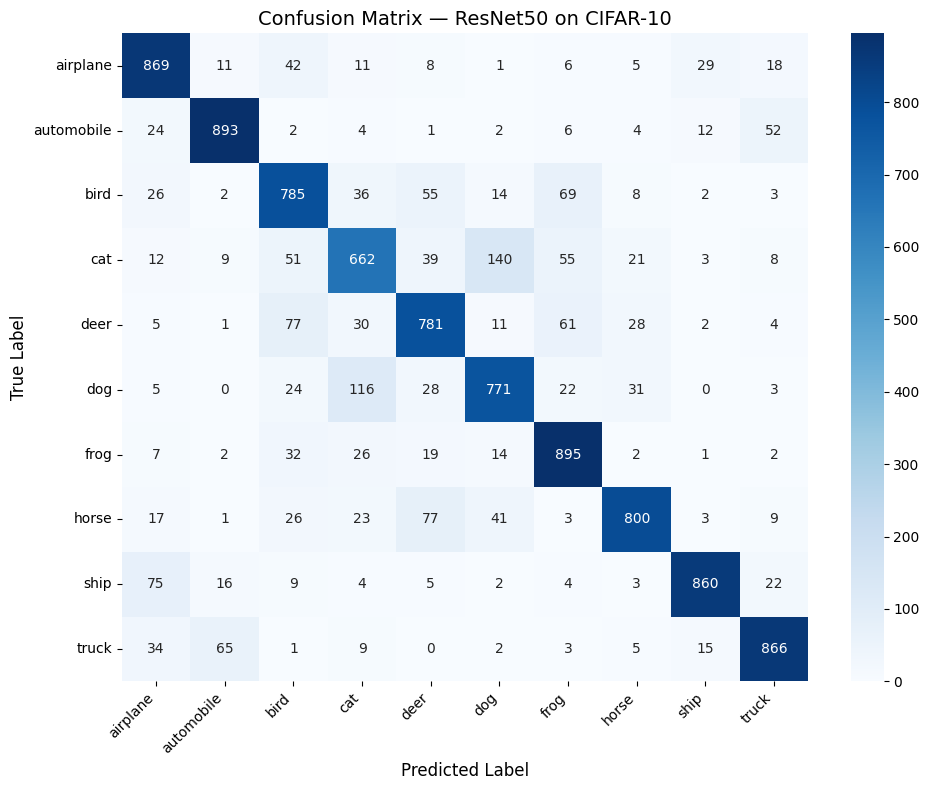

In [7]:
#Per-Class Classification Report

print("\n========== Per-Class Classification Report ==========")
print(classification_report(y_true, y_pred, target_names=class_names))

#Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title('Confusion Matrix — ResNet50 on CIFAR-10', fontsize=14)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label',      fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

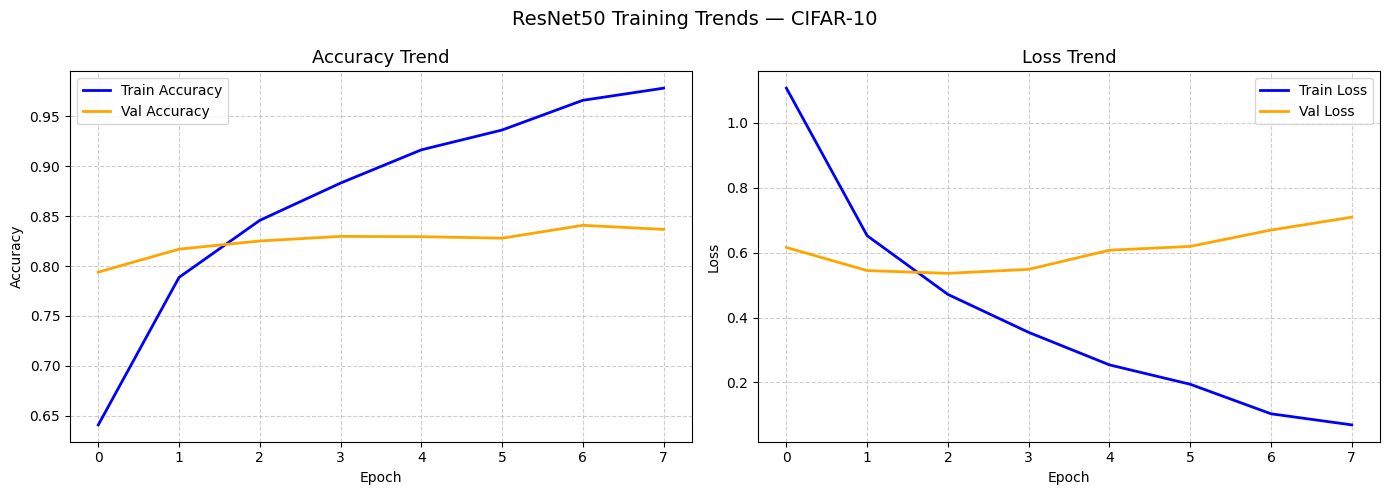

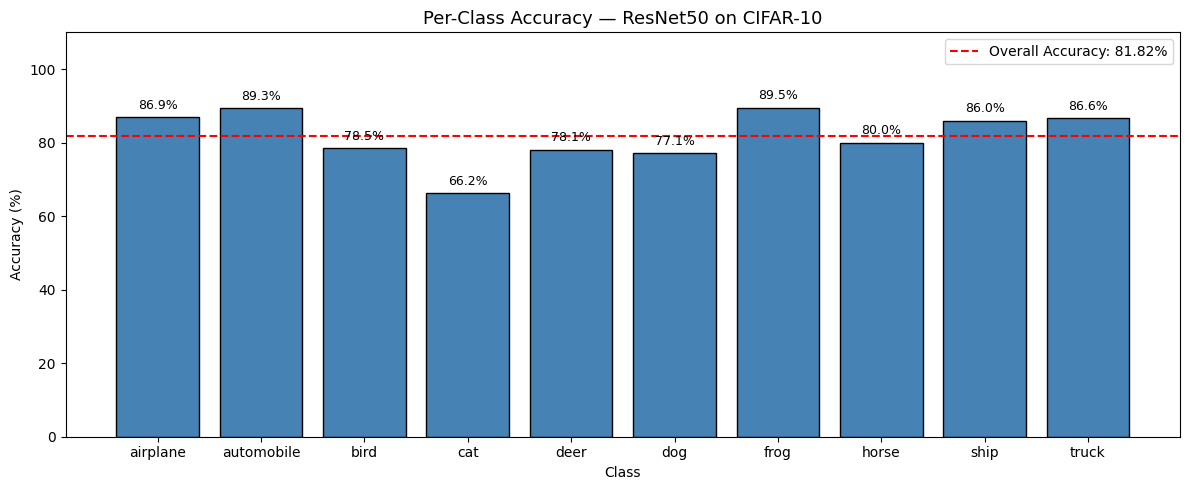

In [8]:
#Accuracy & Loss Curves (from Task 2 history)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history.history['accuracy'],     label='Train Accuracy', color='blue',   linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy',   color='orange', linewidth=2)
axes[0].set_title('Accuracy Trend',  fontsize=13)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.6)

# Loss
axes[1].plot(history.history['loss'],     label='Train Loss', color='blue',   linewidth=2)
axes[1].plot(history.history['val_loss'], label='Val Loss',   color='orange', linewidth=2)
axes[1].set_title('Loss Trend', fontsize=13)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.suptitle("ResNet50 Training Trends — CIFAR-10", fontsize=14)
plt.tight_layout()
plt.show()

#Per-Class Accuracy Bar Chart

per_class_acc = cm.diagonal() / cm.sum(axis=1)

plt.figure(figsize=(12, 5))
bars = plt.bar(class_names, per_class_acc * 100, color='steelblue', edgecolor='black')
plt.axhline(y=accuracy * 100, color='red', linestyle='--', linewidth=1.5, label=f'Overall Accuracy: {accuracy*100:.2f}%')
plt.title('Per-Class Accuracy — ResNet50 on CIFAR-10', fontsize=13)
plt.xlabel('Class')
plt.ylabel('Accuracy (%)')
plt.ylim(0, 110)
plt.legend()

# Annotate bars
for bar, acc in zip(bars, per_class_acc):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 1.5,
             f'{acc*100:.1f}%',
             ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


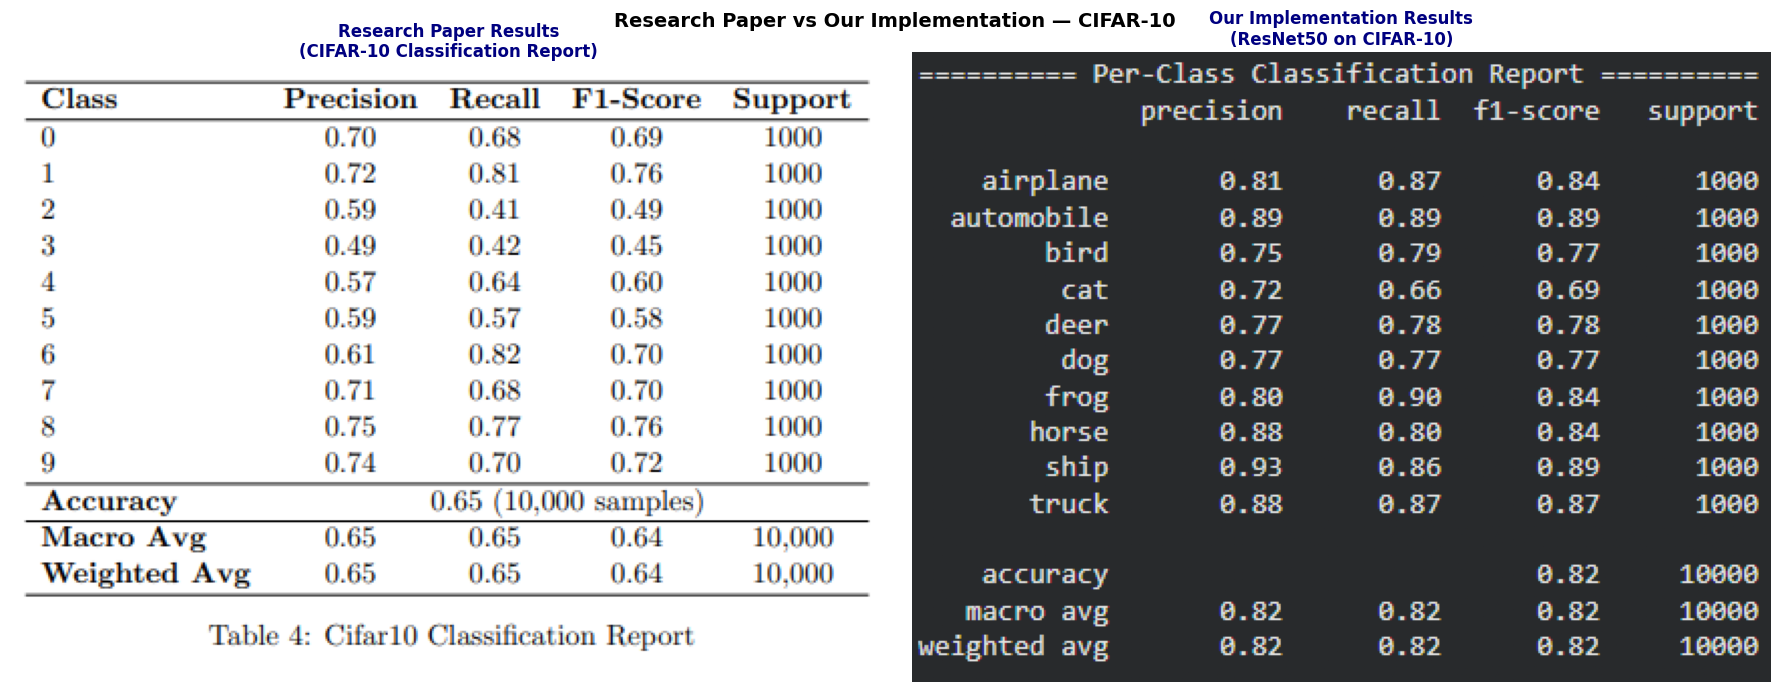

In [10]:
#Comparing Results and Metrics with Research Paper
from google.colab import drive
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Mount Google Drive
drive.mount('/content/drive')

image_path1 = '/content/drive/MyDrive/ResearchPaper-Prac2/metricsScreenshot.png'
image_path2 = '/content/drive/MyDrive/ResearchPaper-Prac2/outputScreenshot.png'

paper_metrics = mpimg.imread(image_path1)
our_metrics = mpimg.imread(image_path2)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

axes[0].imshow(paper_metrics)
axes[0].set_title('Research Paper Results\n(CIFAR-10 Classification Report)',
                  fontsize=12, fontweight='bold', color='navy')
axes[0].axis('off')

axes[1].imshow(our_metrics)
axes[1].set_title('Our Implementation Results\n(ResNet50 on CIFAR-10)',
                  fontsize=12, fontweight='bold', color='navy')
axes[1].axis('off')


plt.suptitle("Research Paper vs Our Implementation — CIFAR-10", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Discussions**

Reasons for better Results from ResNet50 compared to the Paper results:

1. **Different Base Model:** The research paper used a weaker or shallower model (plain CNN), while we used ResNet50 with ImageNet pretrained weights — which already knows edges, textures, shapes from 1.2 million images before even seeing CIFAR-10.

2. **Transfer Learning Advantage:** Your model started with pretrained ImageNet weights — not random weights. The paper may have trained from scratch, which needs far more data and epochs to reach good accuracy.

3. **Fine-tuning Strategy:** We unfroze the last 20 layers which is a well-tested sweet spot — the model adapted high-level features to CIFAR-10 while keeping low-level features (edges, textures) intact from ImageNet.

4. **Adam vs SGD:** You used Adam which adapts the learning rate automatically per parameter — it converges faster and often better on smaller datasets compared to plain SGD which the paper may have used.

**Conclusion and Result Visulaization**

**Declaration**

I, Sanket Rath, confirm that the work submitted in this assignment is my own and has been completed following academic integrity guidelines. The code is uploaded on my GitHub repository account, and the repository link is provided below:

GitHub Repository Link: [Insert GitHub Link]

Signature: Sanket Rath

**Submission Checklist**

✔ Research paper details and summary

✔ Code file (Python Notebook or Script)

✔ Dataset or link to the dataset

✔ Visualizations (if applicable)

✔ Screenshots of model performance metrics

✔ Readme File

✔ Comparison with research paper results